# ResNet-18

Here we are training the ResNet-18, trying out how using a pretrained model, data augmentation, regularization and LR scheduler affect the performance.<br>
We picked ResNet-18 for it's smaller size as the dataset is not big enough and we have problem with overfitting.

In [1]:
from helper_functions import build_dataloaders, build_model, train_model, plot_history, evaluate_model

- No pretraining
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 44.58% | Val: 46.88% | LR: 0.000100
Epoch 2/10 | Train: 61.17% | Val: 37.40% | LR: 0.000100
Epoch 3/10 | Train: 78.30% | Val: 47.15% | LR: 0.000100
Epoch 4/10 | Train: 91.53% | Val: 46.48% | LR: 0.000100
Epoch 5/10 | Train: 96.28% | Val: 45.39% | LR: 0.000100
Epoch 6/10 | Train: 95.81% | Val: 47.97% | LR: 0.000100
Epoch 7/10 | Train: 96.10% | Val: 45.66% | LR: 0.000100
Epoch 8/10 | Train: 94.58% | Val: 47.56% | LR: 0.000100
Epoch 9/10 | Train: 97.66% | Val: 44.17% | LR: 0.000100
Epoch 10/10 | Train: 99.10% | Val: 47.70% | LR: 0.000100


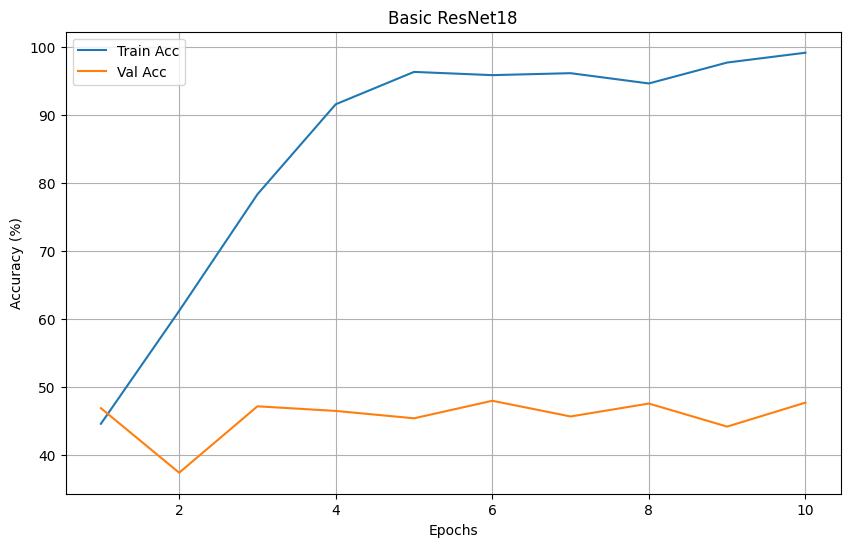


Final Test Accuracy: 49.26%


In [3]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=False
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Basic ResNet18")

test_accuracy = evaluate_model(model, test_loader)

- Using a pretrained model
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 45.09% | Val: 49.05% | LR: 0.000100
Epoch 2/10 | Train: 62.36% | Val: 50.00% | LR: 0.000100
Epoch 3/10 | Train: 75.53% | Val: 52.71% | LR: 0.000100
Epoch 4/10 | Train: 88.06% | Val: 45.39% | LR: 0.000100
Epoch 5/10 | Train: 93.57% | Val: 50.68% | LR: 0.000100
Epoch 6/10 | Train: 93.12% | Val: 50.95% | LR: 0.000100
Epoch 7/10 | Train: 96.96% | Val: 51.22% | LR: 0.000100
Epoch 8/10 | Train: 94.21% | Val: 52.17% | LR: 0.000100
Epoch 9/10 | Train: 97.06% | Val: 50.54% | LR: 0.000100
Epoch 10/10 | Train: 95.21% | Val: 52.30% | LR: 0.000100


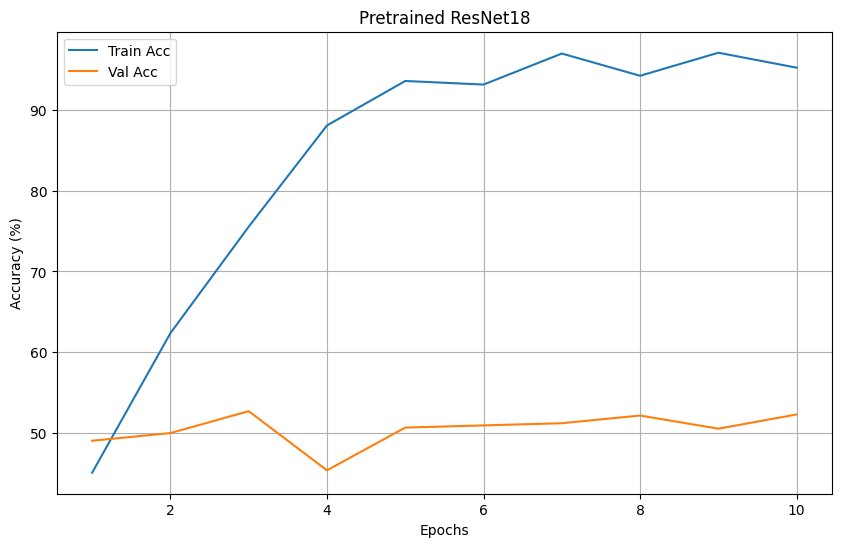


Final Test Accuracy: 54.30%


In [5]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Pretrained ResNet18")

test_accuracy = evaluate_model(model, test_loader)

- Using a pretrained model
- Using augmentation and regularization
- No LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/20 | Train: 34.47% | Val: 44.17% | LR: 0.000100
Epoch 2/20 | Train: 41.65% | Val: 48.37% | LR: 0.000100
Epoch 3/20 | Train: 47.64% | Val: 49.86% | LR: 0.000100
Epoch 4/20 | Train: 50.58% | Val: 51.22% | LR: 0.000100
Epoch 5/20 | Train: 53.97% | Val: 54.74% | LR: 0.000100
Epoch 6/20 | Train: 56.99% | Val: 54.20% | LR: 0.000100
Epoch 7/20 | Train: 60.83% | Val: 54.74% | LR: 0.000100
Epoch 8/20 | Train: 62.48% | Val: 54.07% | LR: 0.000100
Epoch 9/20 | Train: 64.48% | Val: 56.78% | LR: 0.000100
Epoch 10/20 | Train: 68.86% | Val: 55.28% | LR: 0.000100
Epoch 11/20 | Train: 70.24% | Val: 56.64% | LR: 0.000100
Epoch 12/20 | Train: 72.12% | Val: 53.93% | LR: 0.000100
Epoch 13/20 | Train: 74.87% | Val: 54.74% | LR: 0.000100
Epoch 14/20 | Train: 77.20% | Val: 54.07% | LR: 0.000100
Epoch 15/20 | Train: 79.42% | Val: 52.98% | LR: 0.000100
Epoch 16/20 | Train: 80.95% | Val: 57.05% | LR: 0.000100
Epoch 17/20 | Train: 81.05% | Val: 56.10% | LR: 0.000100
Epoch 18/20 | Train: 84.53% | Val: 56.64

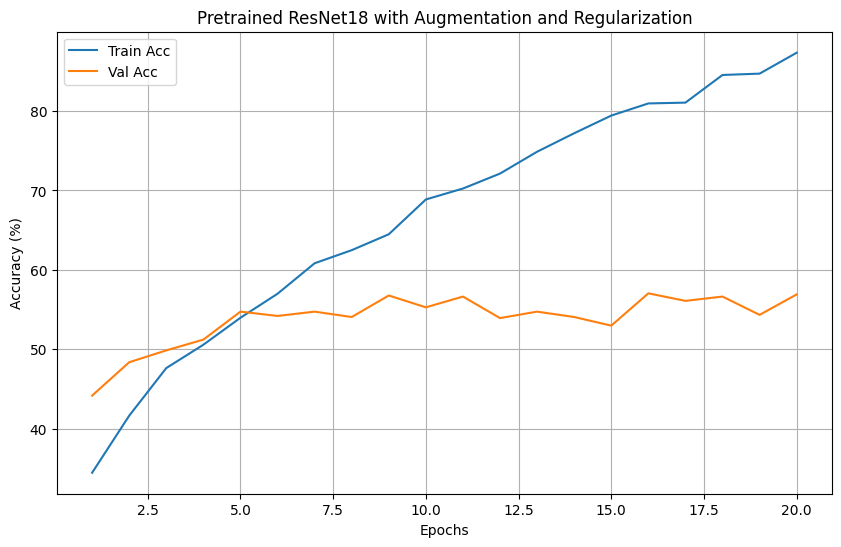


Final Test Accuracy: 61.06%


In [ ]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=20)

plot_history(history, "Pretrained ResNet18 with Augmentation and Regularization")

test_accuracy = evaluate_model(model, test_loader)

- Using a pretrained model
- Using augmentation and regularization
- Using LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/2 | Train: 31.53% | Val: 39.16% | LR: 0.000100
Epoch 2/2 | Train: 37.98% | Val: 47.02% | LR: 0.000100


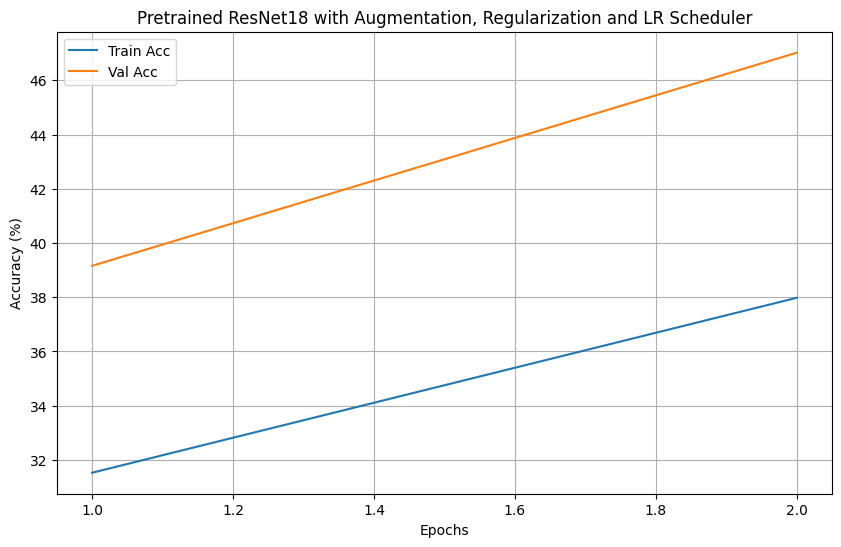


Final Test Accuracy: 44.96%


In [ ]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=20
)

plot_history(history, "Pretrained ResNet18 with Augmentation, Regularization and LR Scheduler")

test_accuracy = evaluate_model(model, test_loader)